In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pylab as pl
from pathlib import Path

In [7]:
file_path = Path.home() / "Desktop" / "FuelConsumption.csv"
df = pd.read_csv(file_path)

In [9]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]
print(msk)
print(train)
print(test)

[False  True  True ...  True  True False]
      ENGINESIZE  CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS
1            2.4          4                   9.6           221
2            1.5          4                   5.9           136
4            3.5          6                  10.6           244
5            3.5          6                  10.0           230
6            3.5          6                  10.1           232
...          ...        ...                   ...           ...
1061         3.2          6                  11.2           258
1062         3.0          6                  11.8           271
1063         3.2          6                  11.5           264
1064         3.0          6                  11.8           271
1065         3.2          6                  11.3           260

[853 rows x 4 columns]
      ENGINESIZE  CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS
0            2.0          4                   8.5           196
3            3.5          6           

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

poly = PolynomialFeatures(degree=2)

train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

test_x = np.asanyarray(train[['ENGINESIZE']])
test_y = np.asanyarray(train[['CO2EMISSIONS']])

train_x_poly = poly.fit_transform (train_x)
train_x_poly

array([[ 1.  ,  2.4 ,  5.76],
       [ 1.  ,  1.5 ,  2.25],
       [ 1.  ,  3.5 , 12.25],
       ...,
       [ 1.  ,  3.2 , 10.24],
       [ 1.  ,  3.  ,  9.  ],
       [ 1.  ,  3.2 , 10.24]], shape=(853, 3))

In [13]:
clf = linear_model.LinearRegression()
train_y_ = clf.fit(train_x_poly, train_y)

print ('Coefficients: ', clf.coef_)
print ('Intercept: ',clf.intercept_)

Coefficients:  [[ 0.         48.63241855 -1.26636555]]
Intercept:  [110.13358069]


Text(0, 0.5, 'CO2EMISSIONS')

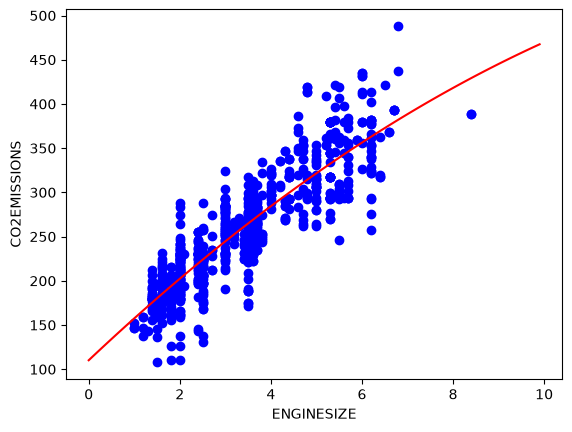

In [14]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
xx = np.arange(0.0, 10.0, 0.1)
yy = clf.intercept_[0] + clf.coef_[0][1]*xx + clf.coef_[0][2]*np.power(xx, 2)

plt.plot(xx, yy, '-r')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')

In [15]:
from sklearn.metrics import r2_score

test_x_poly = poly.fit_transform(test_x)
test_y_ = clf.predict(test_x_poly)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y, test_y_))

Mean absolute error: 23.34
Residual sum of squares (MSE): 932.26
R2-score: 0.77
